In [18]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps

# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

theta shape: (181,)
SU shape: (181,)
First few SU values: [274.50568018 273.77890685 271.60879971 268.02578541 263.07987412]


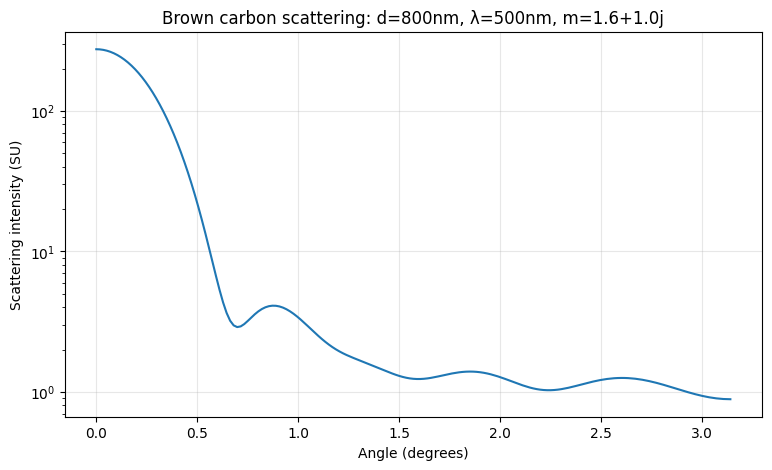

In [19]:
# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm

m = complex(n, k)
theta, SL, SR, SU = ps.ScatteringFunction(
    m, wavelength, diameter,
    minAngle=0, maxAngle=180, angularResolution=1
)

print("theta shape:", theta.shape)
print("SU shape:", SU.shape)
print("First few SU values:", SU[:5])

plt.figure(figsize=(9, 5))
plt.plot(theta, SU)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
N_SAMPLES = 1000

# Pre-allocate arrays
inputs = np.zeros((N_SAMPLES, 2))     # 2 features: wavelength, diameter
outputs = np.zeros((N_SAMPLES, 181))  # 181 angles per curve

# Fixed values for brown carbon
n = 1.6
k = 1.0
m = complex(n, k)

print("Generating training data through physics")

for i in range(N_SAMPLES):
    # Sample random wavelength and diameter
    wavelength = np.random.uniform(450, 550)
    diameter = np.random.uniform(700, 900)
    
    # Run Mie calculation, we'll treat this as the accurate data
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    
    # Store inputs and outputs
    inputs[i] = [wavelength, diameter]
    outputs[i] = SU
    
    if i % 100 == 0:
        print(f"  {i}/{N_SAMPLES} done")

print("\nDone!")
print("Inputs shape:", inputs.shape)
print("Outputs shape:", outputs.shape)

Generating training data through physics
  0/1000 done
  100/1000 done
  200/1000 done
  300/1000 done
  400/1000 done
  500/1000 done
  600/1000 done
  700/1000 done
  800/1000 done
  900/1000 done

Done!
Inputs shape: (1000, 2)
Outputs shape: (1000, 181)


took 4 minutes and 20 seconds for mie theory calculations for 10000 samples

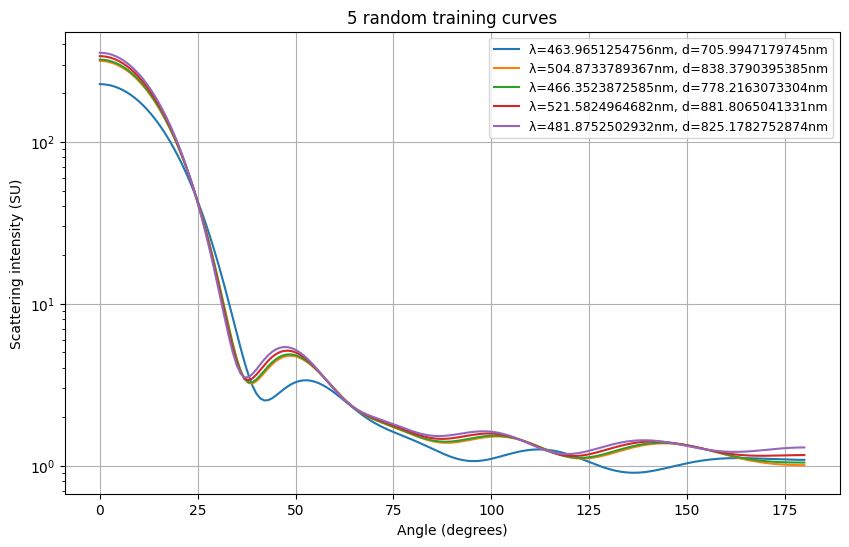

In [21]:
plt.figure(figsize=(10, 6))

# Plot 5 random curves
indices = np.random.choice(N_SAMPLES, 5, replace=False)

# generate lables for each line
for i in indices:
    label = f"λ={inputs[i,0]:.10f}nm, d={inputs[i,1]:.10f}nm"
    plt.plot(outputs[i], label=label)

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("5 random training curves")
plt.yscale('log')
plt.legend(fontsize=9)
plt.grid(True, alpha=1.0)
plt.show()

graphed 5 random training data points, just to see the shape of the results

In [22]:
# 1. Log-transform the outputs
log_outputs = np.log10(outputs)   # base-10 log

# 2. Normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   600-900 → (diameter - 600) / 300
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - 450) / 100   # wavelength
inputs_norm[:, 1] = (inputs[:, 1] - 600) / 300   # diameter

# 3. Train/test split — first 800 train, last 200 test
X_train = inputs_norm[:800] # contains wavelength and diameter
y_train = log_outputs[:800] # amount of light at each angle, values have had log applied
X_test = inputs_norm[800:]
y_test = log_outputs[800:]

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print()
print("Sample input (normalized):", X_train[0])

X_train shape: torch.Size([800, 2])
y_train shape: torch.Size([800, 181])
X_test shape: torch.Size([200, 2])
y_test shape: torch.Size([200, 181])

Sample input (normalized): tensor([0.3745, 0.9671])


Split the data into training and testing data, formatting the data so it's ready for training. Converting numpy arrays into Tensors.

In [23]:
model = nn.Sequential(
    nn.Linear(2, 32),       # input layer: 2 features → 64 neurons
    nn.ReLU(),
    nn.Linear(32, 64),     # hidden layer: 64 → 128
    nn.ReLU(),
    nn.Linear(64, 181),
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=181, bias=True)
)

Total parameters: 13973


building NN layers, applying ReLu between each. Printing the model and counting the number of parameters.

In [24]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()
print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [26]:
N_EPOCHS = 200
BATCH_SIZE = 32

train_losses = []
test_losses = []

n_train = X_train.shape[0]   # 800
n_batches = n_train // BATCH_SIZE  # 800 // 32 = 25

print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)# generates a random permutation of the numbers up to 800
    X_shuffled = X_train[perm] # shuffle the training data according to the permutation
    y_shuffled = y_train[perm] # shuffle the 'answers' for the training data
    
    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0
    for i in range(n_batches):
        start = i * BATCH_SIZE # index work to see where batch starts
        end = start + BATCH_SIZE # index work to see where each batch ends while looping through the batches
        X_batch = X_shuffled[start:end] # diameters and wavelengths used in this batch
        y_batch = y_shuffled[start:end] # light scattered at each angle in this batch
        
        # Standard 5-step training pattern
        pred = model(X_batch) # predict
        loss = loss_fn(pred, y_batch) # get the loss
        
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # records the loss over the batches for graphing
    
    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    with torch.no_grad():
        test_pred = model(X_test) #predict on 200 test examples
        test_loss = loss_fn(test_pred, y_test).item() #compute MSE on test set
        test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

print("\nTraining complete!")

Training: 200 epochs, 25 batches per epoch

Epoch   0  Train Loss: 0.6882973790  Test Loss: 0.5171923637
Epoch  20  Train Loss: 0.0013779183  Test Loss: 0.0013396058
Epoch  40  Train Loss: 0.0009833559  Test Loss: 0.0009628357
Epoch  60  Train Loss: 0.0006857570  Test Loss: 0.0006121714
Epoch  80  Train Loss: 0.0002944215  Test Loss: 0.0002874491
Epoch 100  Train Loss: 0.0001872365  Test Loss: 0.0001679842
Epoch 120  Train Loss: 0.0001015703  Test Loss: 0.0000907038
Epoch 140  Train Loss: 0.0000632028  Test Loss: 0.0000575694
Epoch 160  Train Loss: 0.0000478174  Test Loss: 0.0000415641
Epoch 180  Train Loss: 0.0000432754  Test Loss: 0.0000375662

Training complete!


Training the model. Randomizing the sequence of the training set. Split the set into a training and testing set. Also making sure loss is decreasing over time, ensuring we are approaching a minimum in the cost. Training took 10.7 seconds


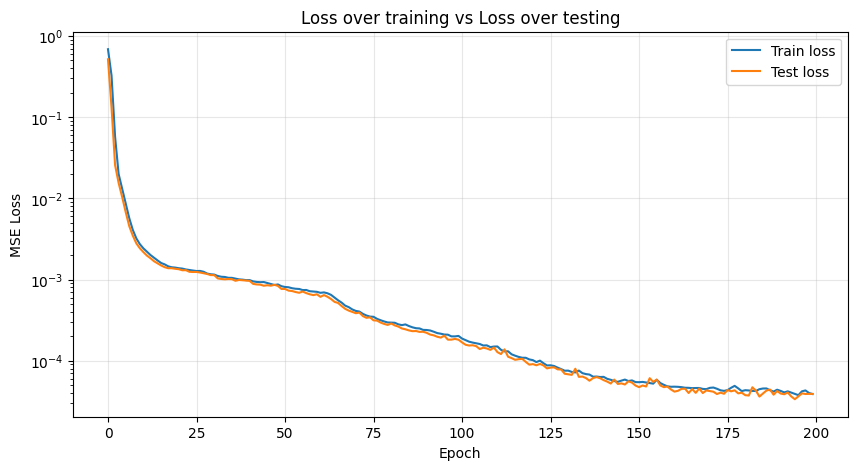

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training vs Loss over testing")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

tensor([2.7548, 2.7532, 2.7483, 2.7401, 2.7286, 2.7137, 2.6955, 2.6738, 2.6486,
        2.6198, 2.5873, 2.5511, 2.5109, 2.4666, 2.4181, 2.3651, 2.3074, 2.2449,
        2.1771, 2.1037, 2.0244, 1.9387, 1.8462, 1.7463, 1.6386, 1.5228, 1.3989,
        1.2678, 1.1318, 0.9964, 0.8714, 0.7709, 0.7092, 0.6914, 0.7093, 0.7479,
        0.7939, 0.8385, 0.8772, 0.9079, 0.9301, 0.9437, 0.9493, 0.9472, 0.9381,
        0.9225, 0.9009, 0.8741, 0.8427, 0.8075, 0.7692, 0.7290, 0.6880, 0.6472,
        0.6080, 0.5716, 0.5390, 0.5110, 0.4880, 0.4699, 0.4563, 0.4464, 0.4394,
        0.4343, 0.4303, 0.4267, 0.4228, 0.4184, 0.4132, 0.4072, 0.4004, 0.3930,
        0.3853, 0.3776, 0.3702, 0.3634, 0.3575, 0.3525, 0.3486, 0.3458, 0.3440,
        0.3429, 0.3424, 0.3421, 0.3418, 0.3411, 0.3398, 0.3376, 0.3344, 0.3300,
        0.3244, 0.3175, 0.3094, 0.3002, 0.2900, 0.2792, 0.2680, 0.2567, 0.2457,
        0.2353, 0.2259, 0.2179, 0.2115, 0.2070, 0.2044, 0.2037, 0.2049, 0.2079,
        0.2123, 0.2178, 0.2241, 0.2310, 

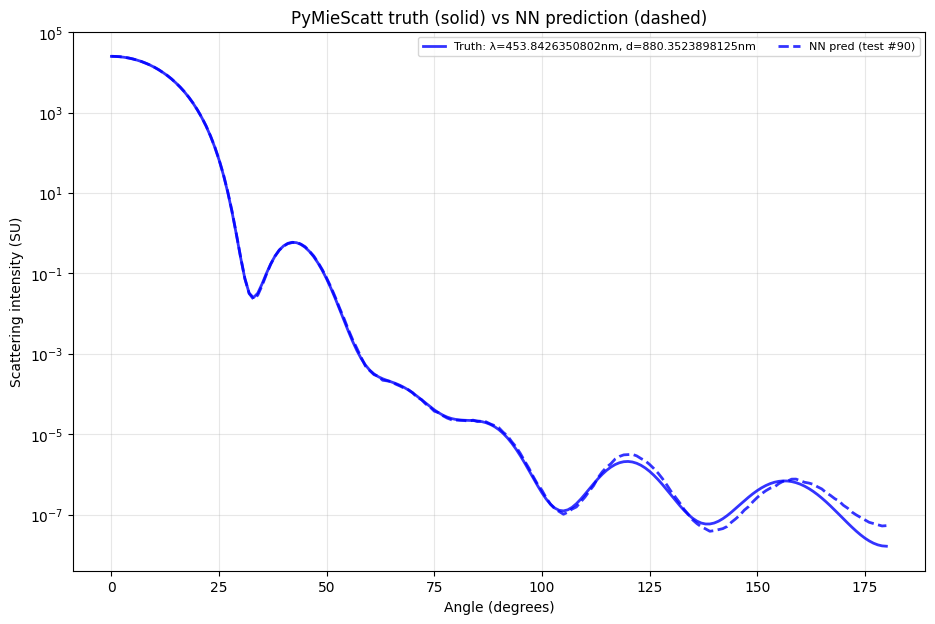

In [28]:
with torch.no_grad():
    test_pred = model(X_test)

# Plot 4 random test cases
plt.figure(figsize=(11, 7))
indices = np.random.choice(len(X_test), 1, replace=False)

print(y_test[indices[0]])
print(test_pred[indices[0]])

# Use different colors for each pair so they're visually distinguishable
colors = ['blue', 'orange', 'green', 'red']

for idx, color in zip(indices, colors):

    # Get the actual physical values (un-normalize)
    norm_w = X_test[idx, 0].item()
    norm_d = X_test[idx, 1].item()
    real_w = norm_w * 100 + 450
    real_d = norm_d * 300 + 600
    
    # Convert log10 back to real brightness values
    true_curve = y_test[idx].numpy() ** 10 # take the log output brightness values and turn them back to their original values
    pred_curve = test_pred[idx].numpy() ** 10 # take the prediction values and turn them back to their original values
    
    # Solid line = truth (PyMieScatt), Dashed line = NN prediction
    plt.plot(true_curve, '-',  color=color, linewidth=2, alpha=0.8,
             label=f"Truth: λ={real_w:.10f}nm, d={real_d:.10f}nm")
    plt.plot(pred_curve, '--', color=color, linewidth=2, alpha=0.8,
             label=f"NN pred (test #{idx})")

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("PyMieScatt truth (solid) vs NN prediction (dashed)")
plt.yscale('log')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

Todo: Still have to try out the tan h compression function between layers. Try to 

Mean squared error (in log space): 1.118524e-04


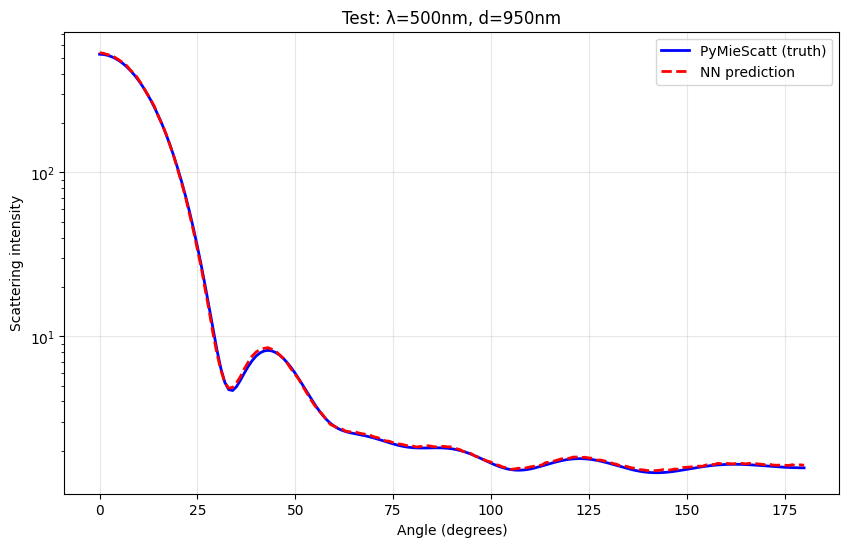

In [29]:
def predict_scattering(wavelength, diameter):
    """Predict scattering curve for a given wavelength and diameter."""
    # Normalize the inputs the same way we did during training
    norm_wavelength = (wavelength - 450) / 100
    norm_diameter   = (diameter - 600) / 300
    
    # Convert to tensor with shape (1, 2) — one example, two features
    input_tensor = torch.FloatTensor([[norm_wavelength, norm_diameter]])
    
    # Run through the network
    with torch.no_grad():
        log_pred = model(input_tensor)
    
    # Convert from log space back to real brightness
    pred_curve = 10 ** log_pred.numpy().flatten()
    
    return pred_curve


def true_scattering(wavelength, diameter):
    """Compute the actual PyMieScatt scattering curve."""
    m = complex(1.6, 1.0)  # brown carbon
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    return SU


# Pick any wavelength and diameter to test
test_wavelength = 500  # nm
test_diameter = 950    # nm

# Get both predictions
nn_curve = predict_scattering(test_wavelength, test_diameter)
true_curve = true_scattering(test_wavelength, test_diameter)

# Calculate error
error = np.mean((np.log10(nn_curve) - np.log10(true_curve))**2)
print(f"Mean squared error (in log space): {error:.6e}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(true_curve, '-',  color='blue', linewidth=2, label='PyMieScatt (truth)')
plt.plot(nn_curve,   '--', color='red',  linewidth=2, label='NN prediction')
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity")
plt.title(f"Test: λ={test_wavelength}nm, d={test_diameter}nm")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

still understanding this part... work in progress. Doesn't look too accurate though. The neural network is able to predict values within it's trained range very well. As soon as it is given a value that is not within the trained range, it starts to perform more poorly.

In [30]:
test_mse = ((model(X_test) - y_test) ** 2).mean().item()
print(f"Final MSE on test set: {test_mse:.8f}")

Final MSE on test set: 0.00003896


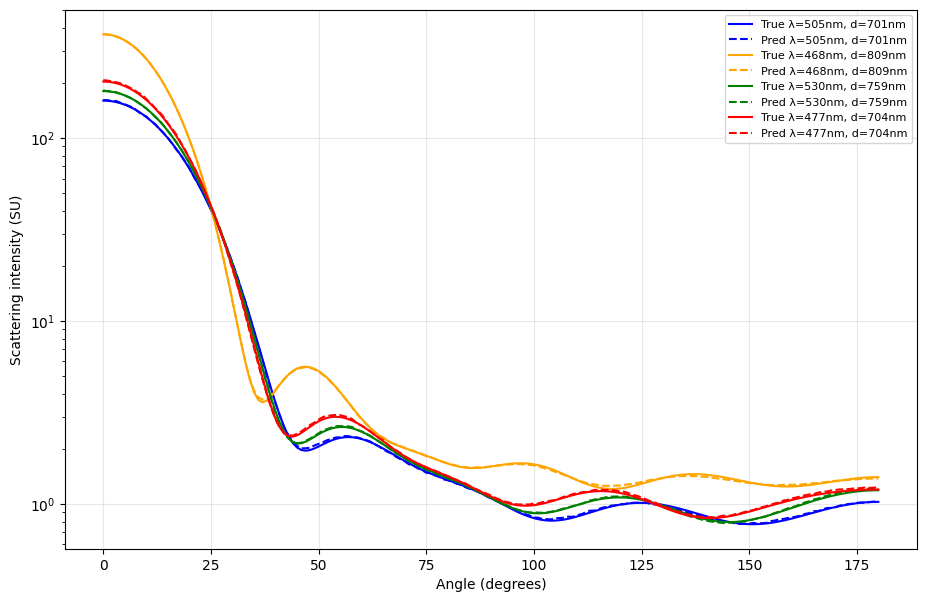

In [32]:
with torch.no_grad():
    test_pred = model(X_test)

particle_indices = np.random.choice(len(X_test), 4, replace=False)
colours = ['blue', 'orange', 'green', 'red']
plt.figure(figsize=(11, 7))

for idx, color in zip(particle_indices, colours):
    true_curve = 10 ** y_test[idx].numpy()      # NOTE: 10 ** x, not x ** 10
    pred_curve = 10 ** test_pred[idx].numpy()

    # Un-normalize inputs for the label
    wavelength = X_test[idx, 0].item() * 100 + 450
    diameter   = X_test[idx, 1].item() * 300 + 600

    label = f"λ={wavelength:.0f}nm, d={diameter:.0f}nm"
    plt.plot(true_curve, '-',  color=color, label=f"True {label}")
    plt.plot(pred_curve, '--', color=color, label=f"Pred {label}")

plt.xlabel("Angle (degrees)"); plt.ylabel("Scattering intensity (SU)")
plt.yscale('log'); plt.legend(fontsize=8); plt.grid(True, alpha=0.3); plt.show()

Neural Network Prediction Time
NN prediction time: 0.0003s
PyMieScatt Prediction Time
PyMieScatt prediction time: 0.0197s
Mean squared error (in log space): 8.090477e-05


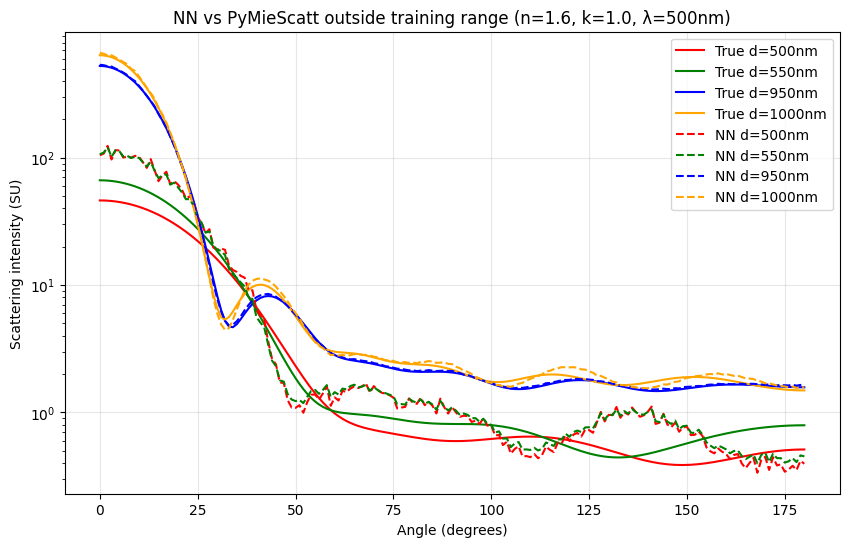

In [37]:
import time

def predict_scattering(wavelength, diameter):
    """Predict scattering curve for given wavelength and diameter."""
    # Match the normalization used in Cell 6
    wavelength_norm = (wavelength - 450) / 100
    diameter_norm   = (diameter   - 600) / 300

    input_tensor = torch.FloatTensor([[wavelength_norm, diameter_norm]])

    with torch.no_grad():
        log_pred = model(input_tensor)

    return 10 ** log_pred.numpy().flatten()


def true_scattering(wavelength, diameter):
    """Ground-truth Mie curve from PyMieScatt (brown carbon: n=1.6, k=1.0)."""
    m = complex(1.6, 1.0)
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    return SU


# --- Single-point speed comparison ---
test_wavelength = 500
test_diameter   = 900

print("Neural Network Prediction Time")
start = time.time()
nn_curve = predict_scattering(test_wavelength, test_diameter)
print(f"NN prediction time: {time.time() - start:.4f}s")

print("PyMieScatt Prediction Time")
start = time.time()
true_curve = true_scattering(test_wavelength, test_diameter)
print(f"PyMieScatt prediction time: {time.time() - start:.4f}s")

error = np.mean((np.log10(nn_curve) - np.log10(true_curve)) ** 2)
print(f"Mean squared error (in log space): {error:.6e}")


# --- Multi-diameter comparison plot ---
# Training range was d = 700–900 nm, so 500/550 are below and 950/1000 are above
true_curve_1 = true_scattering(500, 500)
true_curve_2 = true_scattering(500, 550)
true_curve_3 = true_scattering(500, 950)
true_curve_4 = true_scattering(500, 1000)

nn_curve_1 = predict_scattering(500, 500)
nn_curve_2 = predict_scattering(500, 550)
nn_curve_3 = predict_scattering(500, 950)
nn_curve_4 = predict_scattering(500, 1000)

angles = np.linspace(0, 180, 181)  # degrees — your model outputs 181 angle samples

plt.figure(figsize=(10, 6))
plt.plot(angles, true_curve_1, label='True d=500nm',  color='red',    linestyle='-')
plt.plot(angles, true_curve_2, label='True d=550nm',  color='green',  linestyle='-')
plt.plot(angles, true_curve_3, label='True d=950nm',  color='blue',   linestyle='-')
plt.plot(angles, true_curve_4, label='True d=1000nm', color='orange', linestyle='-')

plt.plot(angles, nn_curve_1, label='NN d=500nm',  color='red',    linestyle='--')
plt.plot(angles, nn_curve_2, label='NN d=550nm',  color='green',  linestyle='--')
plt.plot(angles, nn_curve_3, label='NN d=950nm',  color='blue',   linestyle='--')
plt.plot(angles, nn_curve_4, label='NN d=1000nm', color='orange', linestyle='--')

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("NN vs PyMieScatt outside training range (n=1.6, k=1.0, λ=500nm)")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Running benchmark with 10 repetitions per method...

Run 1/10: NN=0.23ms  PyMieScatt=17.56ms  pyMieDiff=7.46ms
Run 2/10: NN=0.08ms  PyMieScatt=16.29ms  pyMieDiff=7.01ms
Run 3/10: NN=0.13ms  PyMieScatt=16.06ms  pyMieDiff=7.02ms
Run 4/10: NN=0.07ms  PyMieScatt=16.12ms  pyMieDiff=6.99ms
Run 5/10: NN=0.07ms  PyMieScatt=16.13ms  pyMieDiff=7.20ms
Run 6/10: NN=0.07ms  PyMieScatt=16.16ms  pyMieDiff=7.09ms
Run 7/10: NN=0.07ms  PyMieScatt=16.64ms  pyMieDiff=7.03ms
Run 8/10: NN=0.07ms  PyMieScatt=15.69ms  pyMieDiff=6.55ms
Run 9/10: NN=0.09ms  PyMieScatt=15.17ms  pyMieDiff=6.52ms
Run 10/10: NN=0.27ms  PyMieScatt=15.83ms  pyMieDiff=7.54ms

--- Average times ---
NN:         0.12 ms (±0.07 ms)
PyMieScatt: 16.17 ms (±0.59 ms)
pyMieDiff:  7.04 ms (±0.31 ms)


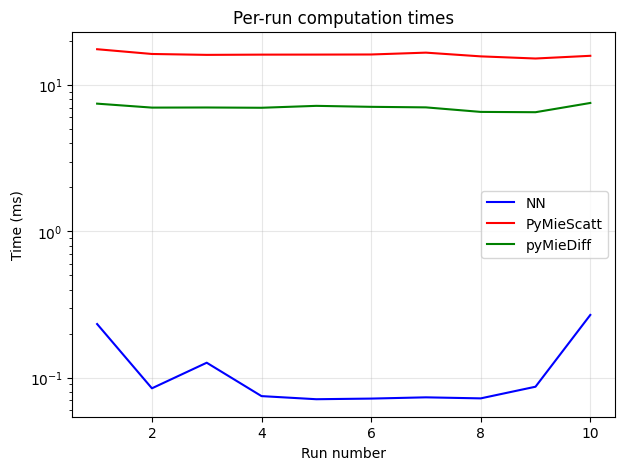

In [40]:
import time
import pymiediff as pmd

# Test parameters — fixed at the NN's training values so all three methods
# compute the same scattering curve.
wavelength = 500
diameter   = 800
n = 1.6
k = 1.0

N_RUNS = 10

nn_times = []
pymiescatt_times = []
pymiediff_times = []

# Warmup — first call to the model has one-time overhead that skews timing
_ = predict_scattering(wavelength, diameter)

print(f"Running benchmark with {N_RUNS} repetitions per method...\n")

for run in range(N_RUNS):
    # --- NN (2-input model: wavelength, diameter only) ---
    start = time.time()
    _ = predict_scattering(wavelength, diameter)
    nn_times.append(time.time() - start)

    # --- PyMieScatt ---
    start = time.time()
    m = complex(n, k)
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    pymiescatt_times.append(time.time() - start)

    # --- pyMieDiff ---
    start = time.time()
    wl0 = torch.tensor([float(wavelength)])
    k0  = 2 * torch.pi / wl0
    p = pmd.Particle(
        r_layers=[diameter / 2],
        mat_layers=[n + k * 1j],
        mat_env=1.00
    )
    theta_t = torch.arange(0, 181) * torch.pi / 181
    angle_scattering = p.get_angular_scattering(k0=k0, theta=theta_t)
    pymiediff_times.append(time.time() - start)

    print(f"Run {run+1}/{N_RUNS}: "
          f"NN={nn_times[-1]*1000:.2f}ms  "
          f"PyMieScatt={pymiescatt_times[-1]*1000:.2f}ms  "
          f"pyMieDiff={pymiediff_times[-1]*1000:.2f}ms")

print(f"\n--- Average times ---")
print(f"NN:         {np.mean(nn_times)*1000:.2f} ms (±{np.std(nn_times)*1000:.2f} ms)")
print(f"PyMieScatt: {np.mean(pymiescatt_times)*1000:.2f} ms (±{np.std(pymiescatt_times)*1000:.2f} ms)")
print(f"pyMieDiff:  {np.mean(pymiediff_times)*1000:.2f} ms (±{np.std(pymiediff_times)*1000:.2f} ms)")

fig, axes = plt.subplots(figsize=(7, 5))
axes.plot(range(1, N_RUNS+1), [t*1000 for t in nn_times],         label='NN',         color='blue')
axes.plot(range(1, N_RUNS+1), [t*1000 for t in pymiescatt_times], label='PyMieScatt', color='red')
axes.plot(range(1, N_RUNS+1), [t*1000 for t in pymiediff_times],  label='pyMieDiff',  color='green')
axes.set_xlabel('Run number')
axes.set_ylabel('Time (ms)')
axes.set_title('Per-run computation times')
axes.set_yscale('log')
axes.legend()
axes.grid(True, alpha=0.3)
plt.show()

In [41]:
print(X_train.shape)

torch.Size([800, 2])
